In [1]:
#1. Load --> Data, Model
#2. Preprocess
#3. Split ( Train, Test)
#4. Design and Implement out model. 
#5. Train
#6. Evaluate
#7. Predict

# libraries

In [55]:

import keras
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from keras.datasets import mnist
from keras.models import Sequential
from keras import layers
from keras.layers import Dense

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Load MNIST

In [53]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Training images: {train_images.shape}")
print(f"Training labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}")
print(f"Test labels: {test_labels.shape}")

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## Visualize Sample Images

Before preprocessing, we visualize some examples from the MNIST dataset.

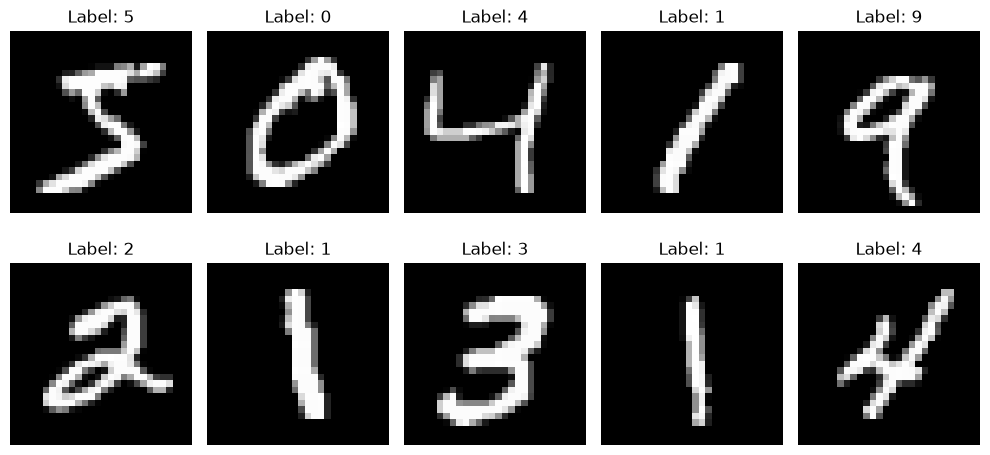

In [54]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

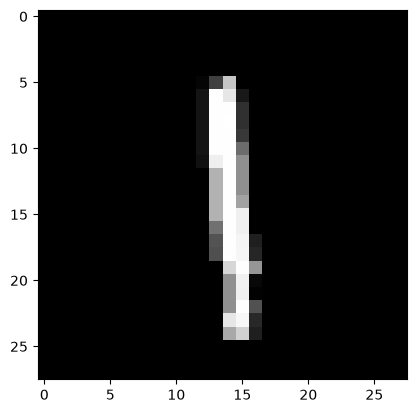

In [52]:
plt.imshow(train_images[8], cmap='gray')

In [9]:
train_labels[8]

np.uint8(1)

## One-Hot Encode Labels

The digit labels are converted into one-hot encoded vectors.

For example:

7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [56]:
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

In [11]:
train_labels[8]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [58]:

## Flatten Images for Dense FFNN

A Dense Neural Network expects a one-dimensional input vector.

Each MNIST image has a shape of:

28 × 28 = 784

Therefore, each image is flattened into a vector of 784 values.
train_images = train_images.reshape(60000, 784)
test_images = test_images.reshape(10000, 784)

SyntaxError: invalid character '×' (U+00D7) (2278809092.py, line 7)

In [13]:
train_images.shape

(60000, 784)

In [14]:
test_images.shape

(10000, 784)

In [15]:
train_images[5]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  13,
        25, 100, 122,   7,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [16]:
train_images[5].shape

(784,)

## Normalize Images

Pixel values in MNIST range from 0 to 255.

We normalize them to the range [0, 1] to make the training process
more stable and efficient.0, 0]

In [57]:
train_images = train_images.astype('float32')/255.0
test_images = test_images.astype('float32')/255.0
print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [18]:
train_images[5]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [19]:
from keras.models import Sequential
from keras.layers import Dense

In [20]:
# Design the model ffnn
model_ffnn = Sequential()
model_ffnn.add(Dense(128, activation='relu'))#Dense, 128, Relu
model_ffnn.add(Dense(64, activation='relu'))#Dense, 64, Relu
model_ffnn.add(Dense(10, activation='softmax'))#Dense, 10, Softmax

In [21]:
model_ffnn.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

E0000 00:00:1788786992.806994   37141 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [22]:
model_ffnn.fit(train_images, train_labels, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9305 - loss: 0.2368
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9703 - loss: 0.0972
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9770 - loss: 0.0705
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9834 - loss: 0.0526
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9869 - loss: 0.0404


In [23]:
model_ffnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 128)              │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [24]:
test_loss, test_acc = model_ffnn.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9756 - loss: 0.0772


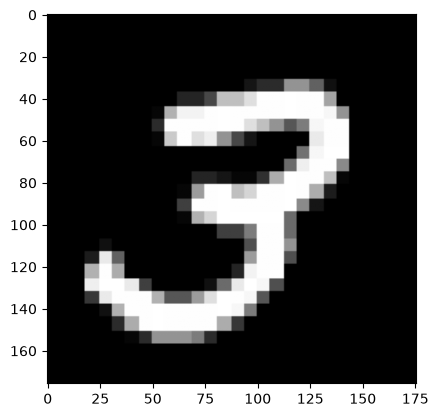

In [25]:
import cv2
test_img = cv2.imread('images.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(test_img, cmap='gray')

In [26]:
test_img_resized = cv2.resize(test_img, (28, 28))
test_img_flatten = test_img_resized.reshape(1, 784)
test_img_normalized = test_img_flatten.astype('float32')/255.0

In [27]:
pred = model_ffnn.predict(test_img_normalized)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


array([[6.6112295e-18, 6.7481983e-14, 1.1725388e-13, 1.0000000e+00,
        3.5843410e-20, 4.4064006e-09, 5.8237049e-22, 3.0277250e-14,
        2.8640267e-12, 2.6252380e-08]], dtype=float32)

In [28]:
import numpy as np 

predicted_label = np.argmax(pred)
predicted_label

np.int64(3)

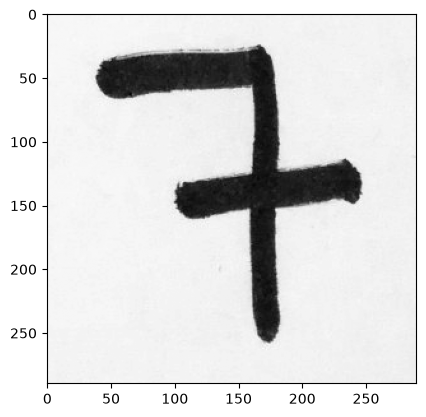

In [29]:
import cv2
test_img = cv2.imread('images1.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(test_img, cmap='gray')

In [30]:
test_img_resized = cv2.resize(test_img, (28, 28))
test_img_flatten = test_img_resized.reshape(1, 784)
test_img_normalized = test_img_flatten.astype('float32')/255.0

In [32]:
pred = model_ffnn.predict(test_img_normalized)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[1.1097973e-06, 1.3146756e-10, 2.0881744e-02, 1.8923640e-06,
        3.5852472e-16, 9.7900909e-01, 4.7096742e-06, 1.0153612e-04,
        1.7390640e-09, 3.7057201e-13]], dtype=float32)

In [33]:
import numpy as np 

predicted_label = np.argmax(pred)
predicted_label

np.int64(5)

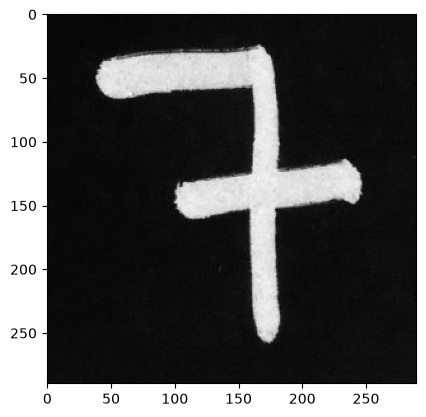

In [34]:

import cv2
test_img = cv2.imread('images1.jpg', cv2.IMREAD_GRAYSCALE)
test_image_inverted =  cv2.bitwise_not(test_img)
plt.imshow(test_image_inverted, cmap='gray')

In [35]:
test_img_resized = cv2.resize(test_image_inverted, (28, 28))
test_img_flatten = test_img_resized.reshape(1, 784)
test_img_normalized = test_img_flatten.astype('float32')/255.0

In [36]:
pred = model_ffnn.predict(test_img_normalized)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[1.1581692e-09, 1.4737782e-07, 9.5462364e-01, 3.8508296e-02,
        1.7090719e-10, 4.5782160e-03, 1.1235370e-03, 6.0431983e-05,
        1.1054015e-03, 2.9554252e-07]], dtype=float32)

In [37]:
import numpy as np 

predicted_label = np.argmax(pred)
predicted_label

np.int64(2)